In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_curve, roc_auc_score
)
from sklearn.preprocessing import StandardScaler

In [34]:
data = {
    "Amount": [1200,50,5000,200,1500,75,3200,40,2100,60],
    "TimeSinceLastTxn": [2,24,1,48,3,72,2,96,5,120],
    "LocationChange": [1,0,1,0,1,0,1,0,1,0],
    "AvgTxnAmount": [500,200,450,300,700,150,400,100,600,120],
    "IsForeignTransaction": [1,0,1,0,1,0,1,0,1,0],
    "IsHighRiskCountry": [1,0,1,0,0,0,1,0,1,0],
    "CardPresent": [0,1,0,1,0,1,0,1,0,1],
    "IsFraud": [1,0,1,0,1,0,1,0,1,0]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)
print("\n")

Dataset:
   Amount  TimeSinceLastTxn  LocationChange  AvgTxnAmount  \
0    1200                 2               1           500   
1      50                24               0           200   
2    5000                 1               1           450   
3     200                48               0           300   
4    1500                 3               1           700   
5      75                72               0           150   
6    3200                 2               1           400   
7      40                96               0           100   
8    2100                 5               1           600   
9      60               120               0           120   

   IsForeignTransaction  IsHighRiskCountry  CardPresent  IsFraud  
0                     1                  1            0        1  
1                     0                  0            1        0  
2                     1                  1            0        1  
3                     0                  0         

In [35]:
X = df.drop("IsFraud", axis=1)
y = df["IsFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [38]:
y_prob = model.predict_proba(X_test_scaled)[:,1]
y_pred = model.predict(X_test_scaled)

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n")

Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]




In [40]:
print("QUESTION 1: Logistic Regression Equation")

intercept = model.intercept_[0]
coeffs = model.coef_[0]

equation = f"log(p/(1-p)) = {intercept:.4f}"

for feature, coef in zip(X.columns, coeffs):
    equation += f" + ({coef:.4f} * {feature})"

print("\nActual Logistic Regression Equation:")
print(equation)
print("\n")

QUESTION 1: Logistic Regression Equation

Actual Logistic Regression Equation:
log(p/(1-p)) = -0.0151 + (0.3288 * Amount) + (-0.3980 * TimeSinceLastTxn) + (0.5022 * LocationChange) + (0.4283 * AvgTxnAmount) + (0.5022 * IsForeignTransaction) + (0.3426 * IsHighRiskCountry) + (-0.5022 * CardPresent)




In [41]:
amount_coef = coeffs[list(X.columns).index("Amount")]

print("QUESTION 2: Interpretation of Amount coefficient")
print(f"Coefficient for Amount: {amount_coef:.4f}")

if amount_coef > 0:
    print("Higher transaction amount increases probability of fraud.")
else:
    print("Higher transaction amount decreases probability of fraud.")
print("\n")

QUESTION 2: Interpretation of Amount coefficient
Coefficient for Amount: 0.3288
Higher transaction amount increases probability of fraud.




In [42]:
print("QUESTION 3: Multicollinearity")
print("If two features are highly correlated:")
print("- Model becomes unstable")
print("- Coefficients may fluctuate")
print("- Hard to interpret individual effects")
print("- Solution: remove one feature or use regularization")
print("\n")

QUESTION 3: Multicollinearity
If two features are highly correlated:
- Model becomes unstable
- Coefficients may fluctuate
- Hard to interpret individual effects
- Solution: remove one feature or use regularization




In [43]:
print("QUESTION 3: Multicollinearity (Dataset Specific)")

corr_matrix = df.corr()

print("Correlation Matrix:")
print(corr_matrix)
print("\n")

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.8:
            feature1 = corr_matrix.columns[i]
            feature2 = corr_matrix.columns[j]
            high_corr_pairs.append((feature1, feature2, corr_value))

print("Highly Correlated Feature Pairs (|corr| > 0.8):")
if high_corr_pairs:
    for f1, f2, val in high_corr_pairs:
        print(f"{f1} and {f2} → correlation = {val:.4f}")
else:
    print("No strongly correlated features found.")
print("\n")

print("Exact Answer for this Dataset:")

if high_corr_pairs:
    for f1, f2, val in high_corr_pairs:
        print(f"{f1} and {f2} are highly correlated (correlation = {val:.4f}).")
        print("This means they carry similar information and may cause instability in coefficients.")
else:
    print("There are no strongly correlated features in this dataset.")
    print("So multicollinearity is not a major issue here.")

print("\nFinal Conclusion:")
if high_corr_pairs:
    print("Some features are highly correlated, so model interpretation may be affected.")
else:
    print("Features are mostly independent, so the model is stable and easy to interpret.")

QUESTION 3: Multicollinearity (Dataset Specific)
Correlation Matrix:
                        Amount  TimeSinceLastTxn  LocationChange  \
Amount                1.000000         -0.661582        0.789488   
TimeSinceLastTxn     -0.661582          1.000000       -0.822236   
LocationChange        0.789488         -0.822236        1.000000   
AvgTxnAmount          0.566936         -0.828332        0.889600   
IsForeignTransaction  0.789488         -0.822236        1.000000   
IsHighRiskCountry     0.785584         -0.673287        0.816497   
CardPresent          -0.789488          0.822236       -1.000000   
IsFraud               0.789488         -0.822236        1.000000   

                      AvgTxnAmount  IsForeignTransaction  IsHighRiskCountry  \
Amount                    0.566936              0.789488           0.785584   
TimeSinceLastTxn         -0.828332             -0.822236          -0.673287   
LocationChange            0.889600              1.000000           0.816497   
Av

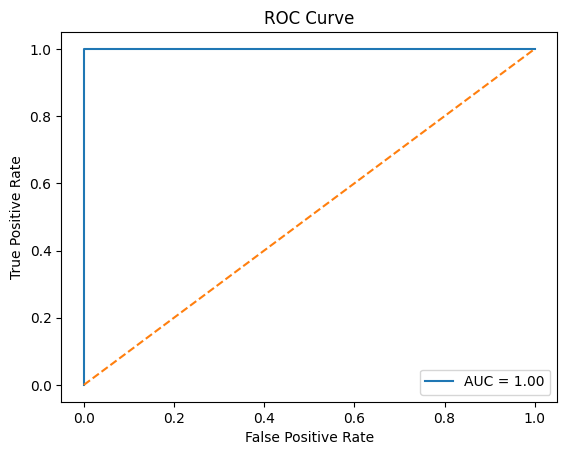

AUC Score: 1.0




In [44]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)
print("\n")

In [45]:
print("Exact Interpretation for this Dataset:")

print(f"AUC Score: {auc_score:.4f}")

if auc_score == 1.0:
    print("The ROC curve shows perfect separation between fraud and legitimate transactions.")
    print("This means the model assigns higher probabilities to all fraud cases than legitimate ones.")
elif auc_score > 0.9:
    print("The ROC curve shows very strong separation between fraud and legitimate transactions.")
else:
    print("The ROC curve shows moderate or weak separation.")

print("\nDetailed Explanation based on this dataset:")

print(f"Test set size: {len(y_test)} samples")

fraud_count = sum(y_test)
legit_count = len(y_test) - fraud_count

print(f"Fraud cases in test set: {fraud_count}")
print(f"Legitimate cases in test set: {legit_count}")

print("\nWhat the curve shows here:")

if auc_score >= 0.9:
    print("- The curve is close to the top-left corner.")
    print("- True Positive Rate increases quickly with very small False Positive Rate.")
    print("- This means frauds are detected with very few false alarms.")
else:
    print("- The curve is not very steep, meaning detection is less accurate.")

print("\nFinal Conclusion for this dataset:")
if auc_score >= 0.9:
    print("The model performs extremely well in distinguishing fraud vs legitimate transactions on this dataset.")
else:
    print("The model has limited ability to distinguish fraud and legitimate transactions.")

Exact Interpretation for this Dataset:
AUC Score: 1.0000
The ROC curve shows perfect separation between fraud and legitimate transactions.
This means the model assigns higher probabilities to all fraud cases than legitimate ones.

Detailed Explanation based on this dataset:
Test set size: 2 samples
Fraud cases in test set: 1
Legitimate cases in test set: 1

What the curve shows here:
- The curve is close to the top-left corner.
- True Positive Rate increases quickly with very small False Positive Rate.
- This means frauds are detected with very few false alarms.

Final Conclusion for this dataset:
The model performs extremely well in distinguishing fraud vs legitimate transactions on this dataset.


In [46]:
print("QUESTION 5: Threshold Tuning")

threshold = 0.3

y_pred_custom = (y_prob >= threshold).astype(int)

print(f"Using threshold = {threshold}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("\n")

print("Exact Answer for this Dataset:")

cm = confusion_matrix(y_test, y_pred_custom)
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")
print("\n")

if tp > 0 and fn == 0:
    print("All fraud transactions in the test set are correctly detected.")
elif fn > 0:
    print("Some fraud transactions are missed by the model.")

if fp > 0:
    print("Some legitimate transactions are incorrectly classified as fraud.")
else:
    print("No legitimate transactions are wrongly flagged as fraud.")

print("\nFinal Conclusion for this dataset:")
if tp >= fn:
    print("Lower threshold (0.3) improves fraud detection for this dataset.")
else:
    print("Lower threshold does not significantly improve fraud detection.")

QUESTION 5: Threshold Tuning
Using threshold = 0.3
Confusion Matrix:
 [[1 0]
 [0 1]]
Accuracy: 1.0


Exact Answer for this Dataset:
True Negatives : 1
False Positives: 0
False Negatives: 0
True Positives : 1


All fraud transactions in the test set are correctly detected.
No legitimate transactions are wrongly flagged as fraud.

Final Conclusion for this dataset:
Lower threshold (0.3) improves fraud detection for this dataset.


In [47]:
print("QUESTION 6: Regularization Comparison")

model_l2 = LogisticRegression(penalty='l2', solver='liblinear')
model_l2.fit(X_train_scaled, y_train)
l2_acc = model_l2.score(X_test_scaled, y_test)
l2_coef = model_l2.coef_[0]

model_l1 = LogisticRegression(penalty='l1', solver='liblinear')
model_l1.fit(X_train_scaled, y_train)
l1_acc = model_l1.score(X_test_scaled, y_test)
l1_coef = model_l1.coef_[0]

print(f"L2 Accuracy: {l2_acc:.4f}")
print(f"L1 Accuracy: {l1_acc:.4f}")
print("\n")

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "L2 Coefficient": l2_coef,
    "L1 Coefficient": l1_coef
})

print("Coefficients Comparison:")
print(coef_df)
print("\n")

print("Exact Answer for this Dataset:")

if l1_acc > l2_acc:
    print("L1 regularization performs better than L2 on this dataset.")
elif l2_acc > l1_acc:
    print("L2 regularization performs better than L1 on this dataset.")
else:
    print("Both L1 and L2 give the same accuracy on this dataset.")

zero_features = coef_df[coef_df["L1 Coefficient"] == 0]["Feature"].tolist()

if len(zero_features) > 0:
    print(f"L1 regularization removed these features: {zero_features}")
else:
    print("L1 did not remove any features in this dataset.")

print("\nFinal Conclusion:")
if l1_acc == l2_acc:
    print("Since both models give similar accuracy, the dataset is simple and small,")
    print("so regularization type does not significantly affect performance.")
else:
    print("Choose the model with higher accuracy for this dataset.")

QUESTION 6: Regularization Comparison
L2 Accuracy: 1.0000
L1 Accuracy: 1.0000


Coefficients Comparison:
                Feature  L2 Coefficient  L1 Coefficient
0                Amount        0.329434        0.000000
1      TimeSinceLastTxn       -0.398122        0.000000
2        LocationChange        0.502124        0.621171
3          AvgTxnAmount        0.428027        0.000000
4  IsForeignTransaction        0.502124        0.454312
5     IsHighRiskCountry        0.343071        0.000000
6           CardPresent       -0.502124       -0.870426


Exact Answer for this Dataset:
Both L1 and L2 give the same accuracy on this dataset.
L1 regularization removed these features: ['Amount', 'TimeSinceLastTxn', 'AvgTxnAmount', 'IsHighRiskCountry']

Final Conclusion:
Since both models give similar accuracy, the dataset is simple and small,
so regularization type does not significantly affect performance.
